In [1]:
# Import necessary libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Load test module for sanity check
from test_utils import test

Data Generation
===

In [5]:
np.random.seed(10)
P, Q = (np.random.rand(i, 2) for i in (4, 5)) # return two matrix with 'i' rows and 2 cols (for x & y coord)
P_big, Q_big = (np.random.rand(i, 80) for i in (100, 120))

print(P, "\n\n", Q)

'''
np.random.rand(i, 2) for i in (4,5)
    - This creates a matrix with 'i' rows and 2 columns, filled with random numbers between 0 and 1.
    - When i = 4, you get a 4x2 matrix.
    - When i = 5, you get a 5x2 matrix.

''';

[[0.77132064 0.02075195]
 [0.63364823 0.74880388]
 [0.49850701 0.22479665]
 [0.19806286 0.76053071]] 

 [[0.16911084 0.08833981]
 [0.68535982 0.95339335]
 [0.00394827 0.51219226]
 [0.81262096 0.61252607]
 [0.72175532 0.29187607]]


Solution
===

In [38]:
def naive(P, Q):
    """
    A naive solution for finding pairvise distances between poins in P and Q

    Args:
        P: numpy array of shape=(p, 2)
        Q: numpy array of shape=(q, 2)
    Returns:
        D: numpy array of shape=(p, q)

    >>> naive(np.array([[0, 1]]), np.array([[2, 3], [4, 5]]))
    array([[2.82842712, 5.65685425]])
    """
    result = np.zeros((P.shape[0], Q.shape[0]))
    for i, p_point in enumerate(P):
        for j, q_point in enumerate(Q):
            result[i,j] = np.sum( (p_point - q_point)**2 ) 
            # it does: 
                # (p_point - q_point) --> [(x1-x2), (y1-y2)]
                # **2 --> [(x1-x2)^2 , (y1-y2)^2] 
                # np.sum() --> (x1-x2)^2 + (y1-y2)^2 --> ONE val
        
    return np.sqrt(result)

print("P:\n", P, "\n\nQ:\n", Q, "\n\n", "Output:\n",naive(P, Q))
test(naive)

P:
 [[0.77132064 0.02075195]
 [0.63364823 0.74880388]
 [0.49850701 0.22479665]
 [0.19806286 0.76053071]] 

Q:
 [[0.16911084 0.08833981]
 [0.68535982 0.95339335]
 [0.00394827 0.51219226]
 [0.81262096 0.61252607]
 [0.72175532 0.29187607]] 

 Output:
 [[0.60599073 0.93659449 0.91124856 0.59321356 0.27561751]
 [0.80746999 0.21102354 0.67268649 0.22495084 0.46534491]
 [0.35654215 0.75217493 0.57200052 0.49900068 0.23310825]
 [0.67281411 0.52407472 0.31520226 0.63212897 0.70277376]]
✅ Your `naive` passed 1 tests.


### Use matching indices

Instead of iterating through indices, one can use them directly to parallelize the operations with Numpy.

In [54]:
rows, cols = np.indices((P.shape[0], Q.shape[0])) # np.indices((m,n)) generates a grid of indices for an array with shape (m, n).
print("rows:\n", rows, "\n")
print("cols:\n", cols)

rows:
 [[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]] 

cols:
 [[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]


In [ ]:
print(P[rows.ravel()], end="\n\n") # rows.ravel() = [0,0,0,0,0, 1,1,1,1,1....] --> P[ rows.ravel() ] --> [ P[0],P[0],P[0],P[0],P[0], P[1],P[1],P[1],P[1],P[1], ...]
print(Q[cols.ravel()])             # cols.ravel() = [0,1,2,3,4, 0,1,2,3,4....] --> Q[ cols.ravel() ] --> [ Q[0],Q[1],Q[2],Q[3],Q[4], Q[0],Q[1],Q[2],Q[3],Q[4], ...]

[[0.77132064 0.02075195]
 [0.77132064 0.02075195]
 [0.77132064 0.02075195]
 [0.77132064 0.02075195]
 [0.77132064 0.02075195]
 [0.63364823 0.74880388]
 [0.63364823 0.74880388]
 [0.63364823 0.74880388]
 [0.63364823 0.74880388]
 [0.63364823 0.74880388]
 [0.49850701 0.22479665]
 [0.49850701 0.22479665]
 [0.49850701 0.22479665]
 [0.49850701 0.22479665]
 [0.49850701 0.22479665]
 [0.19806286 0.76053071]
 [0.19806286 0.76053071]
 [0.19806286 0.76053071]
 [0.19806286 0.76053071]
 [0.19806286 0.76053071]]

[[0.16911084 0.08833981]
 [0.68535982 0.95339335]
 [0.00394827 0.51219226]
 [0.81262096 0.61252607]
 [0.72175532 0.29187607]
 [0.16911084 0.08833981]
 [0.68535982 0.95339335]
 [0.00394827 0.51219226]
 [0.81262096 0.61252607]
 [0.72175532 0.29187607]
 [0.16911084 0.08833981]
 [0.68535982 0.95339335]
 [0.00394827 0.51219226]
 [0.81262096 0.61252607]
 [0.72175532 0.29187607]
 [0.16911084 0.08833981]
 [0.68535982 0.95339335]
 [0.00394827 0.51219226]
 [0.81262096 0.61252607]
 [0.72175532 0.29187607

In [75]:
def with_indices(P, Q):
    """
    An optimized solution using matching indices

    Args:
        P: numpy array of shape=(p, 2)
        Q: numpy array of shape=(q, 2)
    Returns:
        D: numpy array of shape=(p, q)

    >>> with_indices(np.array([[0, 1]]), np.array([[2, 3], [4, 5]]))
    array([[2.82842712, 5.65685425]])
    """
    rows, cols = np.indices((P.shape[0], Q.shape[0]))
    result = np.sum( ( P[rows.ravel()] - Q[cols.ravel()] ) ** 2 , axis=1)
    result = np.sqrt(result)
    result = result.reshape(P.shape[0], Q.shape[0])
    return result

test(with_indices)

✅ Your `with_indices` passed 1 tests.


### Use a library

`scipy` is the equivalent of matlab toolboxes and have a lot to offer. Actually the pairwise computation is part of the library through the `spatial` module.

In [76]:
from scipy.spatial.distance import cdist


def scipy_version(P, Q):
    """
    A solution using scipy

    Args:
        P: numpy array of shape=(p, 2)
        Q: numpy array of shape=(q, 2)

    Returns:
        D: numpy array of shape=(p, q)

    >>> scipy_version(np.array([[0, 1]]), np.array([[2, 3], [4, 5]]))
    array([[2.82842712, 5.65685425]])
    """
    return cdist(P, Q)

### Numpy Magic

In [77]:
def tensor_broadcasting(P, Q):
    """
    A solution using tensor broadcasting

    Args:
        P: numpy array of shape=(p, 2)
        Q: numpy array of shape=(q, 2)

    Returns:
        D: numpy array of shape=(p, q)

    >>> tensor_broadcasting(np.array([[0, 1]]), np.array([[2, 3], [4, 5]]))
    array([[2.82842712, 5.65685425]])
    """
    return np.sqrt(np.sum((P[:, np.newaxis, :] - Q[np.newaxis, :, :]) ** 2, axis=2))

# Compare methods

In [80]:
methods = [
    naive,
    #naive_2,  # This is another possible solution. Feel free to comment it out if you have only one solution.
    with_indices,
    #with_indices_2,  # This is another possible solution. Feel free to comment it out if you have only one solution.
    scipy_version,
    tensor_broadcasting,
]
timers = []
for f in methods:
    r = %timeit -o f(P_big, Q_big)
    timers.append(r)

87.8 ms ± 3.94 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
5.21 ms ± 370 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
646 μs ± 42.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
3.49 ms ± 58.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


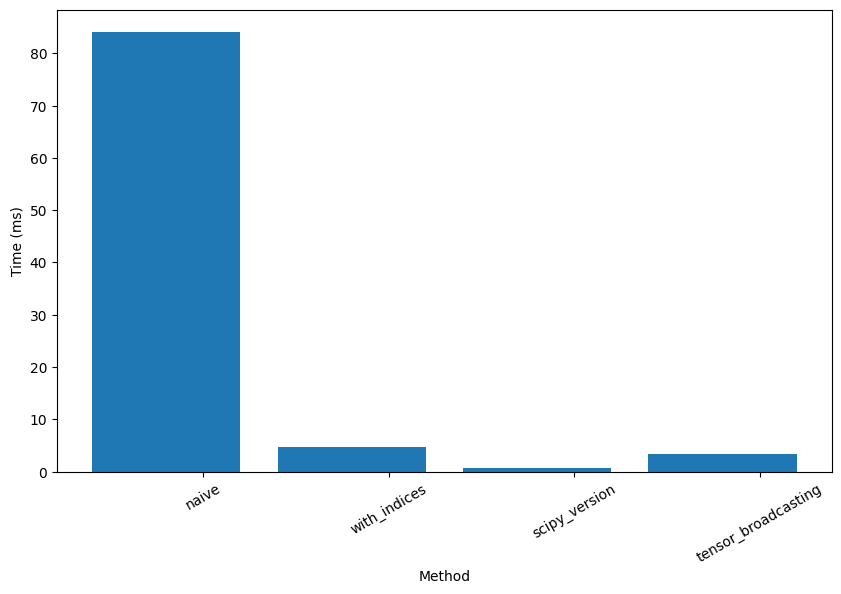

In [81]:
plt.figure(figsize=(10, 6))
plt.bar(
    np.arange(len(methods)), [r.best * 1000 for r in timers], log=False
)  # Set log to True for logarithmic scale
plt.xticks(np.arange(len(methods)) + 0.2, [f.__name__ for f in methods], rotation=30)
plt.xlabel("Method")
plt.ylabel("Time (ms)")
plt.show()